In [1]:
import joblib             as jlb
import matplotlib.pyplot  as plt
import warnings
import pandas as pd
warnings.filterwarnings('ignore')
from collections          import Counter
from Algorithm            import KMEANS
from pyclustering.utils import timedcall
from Dataprepare.data_processing import D,data_pca
from utils import Kmeans_silhouette_analysis,Kmeans_davies_bouldin_analysis,Kmeans_Inertia_analysis


In [2]:
features=[
 'balance',
 'purchases',
 'cash_advance'
]
data=D[features].copy()
# Kmeans_silhouette_analysis(data, k_range=range(2, 8))

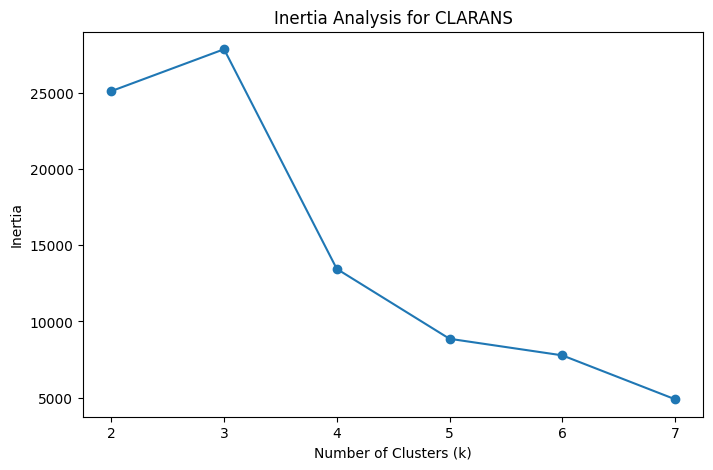

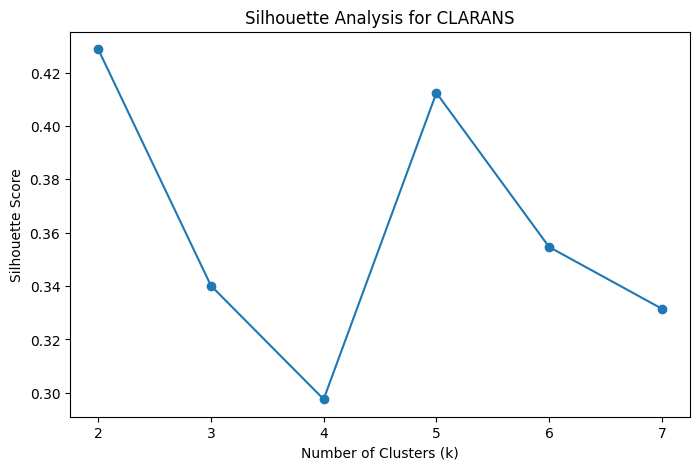

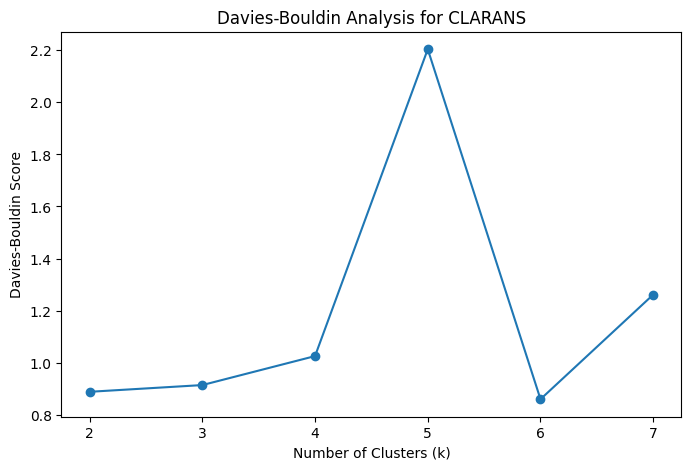

In [3]:
Kmeans_Inertia_analysis(data, k_range=range(2, 8))
Kmeans_silhouette_analysis(data, k_range=range(2, 8))
Kmeans_davies_bouldin_analysis(data, k_range=range(2, 8))

In [11]:
##------------------------------------------------------------------------------
## Xây dựng mô hình kMeans
##------------------------------------------------------------------------------
k     = 3
Kmeans_model = KMEANS(data,n_clusters = k)
(ticks,results) = timedcall(Kmeans_model.fit)  # xây dựng mô hình
print(f"Thời gian chạy: {ticks:.4f} giây")

Thời gian chạy: 0.2225 giây


In [12]:
## Lưu trữ mô hình để khai thác về sau
jlb.dump(Kmeans_model,'../customer_clustering/Output/kMeans.mdl')

['../customer_clustering/Output/kMeans.mdl']

In [13]:
## Khai thác mô hình đã được xây dựng
Loaded_Kmeans_model = jlb.load('../customer_clustering/Output/kMeans.mdl')

In [14]:
## Các trọng tâm
print(f'*** {k} trọng tâm:')
print(Loaded_Kmeans_model.get_centroids())

*** 3 trọng tâm:
[[ 1.27814963  0.90681215 -0.93789448  0.        ]
 [-1.92111926 -0.12577004 -0.93789448  4.        ]
 [-1.12304901  0.2041122  -0.93789448  4.        ]]


In [15]:
## Kết quả gom cụm khách hàng
centroids       = Loaded_Kmeans_model.get_centroids()
data['cluster'] = Loaded_Kmeans_model.get_labels()
print(data.head(5))
print('\nKích thước các clusters:', Counter(Loaded_Kmeans_model.get_labels()))
print('\nClusters lớn nhất:', Counter(Loaded_Kmeans_model.get_labels()).most_common(1))

    balance  purchases  cash_advance  cluster
0 -1.334707  -0.123312     -0.937894        2
1  0.952729  -1.686451      1.518315        0
2  0.821135   0.589495     -0.937894        0
3  0.233137  -0.717052     -0.937894        0
4  0.651839   0.775749     -0.937894        0

Kích thước các clusters: Counter({np.int64(2): 4142, np.int64(0): 3688, np.int64(1): 806})

Clusters lớn nhất: [(np.int64(2), 4142)]


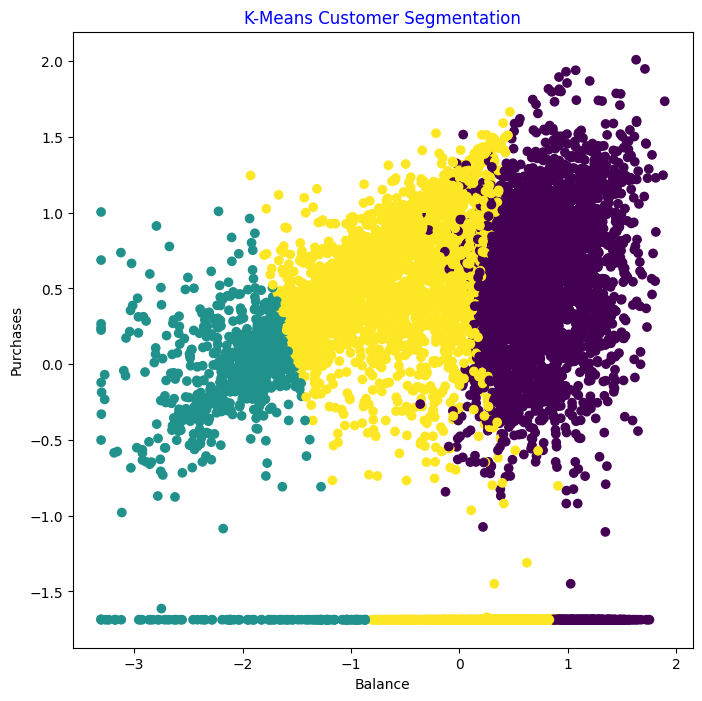

In [16]:
## Biểu diễn trực quan
plt.figure(figsize = (8, 8))
plt.scatter(
    data['balance'],
    data['purchases'],
    c=data['cluster']
)
plt.xlabel('Balance')
plt.ylabel('Purchases')
plt.title("K-Means Customer Segmentation", color = "blue")
plt.show()

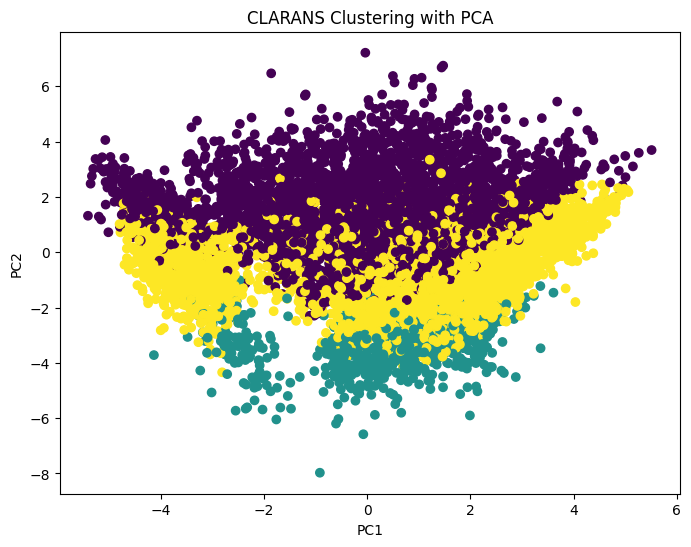

In [17]:

plt.figure(figsize=(8,6))
plt.scatter(data_pca[:,0], data_pca[:,1], c=data['cluster'])

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('CLARANS Clustering with PCA')
plt.show()